# Goa Dark Store Expansion Strategy
## Blinkit Market Expansion Analysis - New City Entry
This notebook optimizes dark store locations for Blinkit's expansion into Goa by analyzing Zomato delivery data and performing clustering analysis.

## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
import folium
from folium.plugins import MarkerCluster
import warnings
warnings.filterwarnings('ignore')

# Set style for visualization
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

## 2. Load and Explore Zomato Dataset

In [2]:
# Load dataset
df = pd.read_csv("Zomato_Data.csv")

# Display basic information
print("Dataset Shape:", df.shape)
print("\nColumn Names and Data Types:")
print(df.dtypes)
print("\nFirst few rows:")
df.head()

Dataset Shape: (45584, 20)

Column Names and Data Types:
ID                              object
Delivery_person_ID              object
Delivery_person_Age            float64
Delivery_person_Ratings        float64
Restaurant_latitude            float64
Restaurant_longitude           float64
Delivery_location_latitude     float64
Delivery_location_longitude    float64
Order_Date                      object
Time_Orderd                     object
Time_Order_picked               object
Weather_conditions              object
Road_traffic_density            object
Vehicle_condition                int64
Type_of_order                   object
Type_of_vehicle                 object
multiple_deliveries            float64
Festival                        object
City                            object
Time_taken (min)                 int64
dtype: object

First few rows:


,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken (min)
0,0xcdcd,DEHRES17DEL01,36.0,4.2,30.327968,78.046106,30.397968,78.116106,12-02-2022,21:55,22:10,Fog,Jam,2,Snack,motorcycle,3.0,No,Metropolitian,46
1,0xd987,KOCRES16DEL01,21.0,4.7,10.003064,76.307589,10.043064,76.347589,13-02-2022,14:55,15:05,Stormy,High,1,Meal,motorcycle,1.0,No,Metropolitian,23
2,0x2784,PUNERES13DEL03,23.0,4.7,18.562450,73.916619,18.652450,74.006619,04-03-2022,17:30,17:40,Sandstorms,Medium,1,Drinks,scooter,1.0,No,Metropolitian,21
3,0xc8b6,LUDHRES15DEL02,34.0,4.3,30.899584,75.809346,30.919584,75.829346,13-02-2022,09:20,09:30,Sandstorms,Low,0,Buffet,motorcycle,0.0,No,Metropolitian,20
4,0xdb64,KNPRES14DEL02,24.0,4.7,26.463504,80.372929,26.593504,80.502929,14-02-2022,19:50,20:05,Fog,Jam,1,Snack,scooter,1.0,No,Metropolitian,41


In [3]:
# Display missing values
print("Missing Values:")
print(df.isnull().sum())
print("\nBasic Statistics:")
df.describe()

Missing Values:
ID                                0
Delivery_person_ID                0
Delivery_person_Age            1854
Delivery_person_Ratings        1908
Restaurant_latitude               0
Restaurant_longitude              0
Delivery_location_latitude        0
Delivery_location_longitude       0
Order_Date                        0
Time_Orderd                    1731
Time_Order_picked                 0
Weather_conditions              616
Road_traffic_density            601
Vehicle_condition                 0
Type_of_order                     0
Type_of_vehicle                   0
multiple_deliveries             993
Festival                        228
City                           1200
Time_taken (min)                  0
dtype: int64

Basic Statistics:


,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Vehicle_condition,multiple_deliveries,Time_taken (min)
count,43730.000000,43676.000000,45584.000000,45584.000000,45584.000000,45584.000000,45584.000000,44591.000000,45584.000000
mean,29.566911,4.633774,17.017948,70.229684,17.465480,70.844161,1.023385,0.744635,26.293963
std,5.815064,0.334744,8.185674,22.885575,7.335562,21.120578,0.839055,0.572510,9.384298
min,15.000000,1.000000,-30.905562,-88.366217,0.010000,0.010000,0.000000,0.000000,10.000000
25%,25.000000,4.500000,12.933284,73.170000,12.988453,73.280000,0.000000,0.000000,19.000000
50%,30.000000,4.700000,18.551440,75.897963,18.633934,76.002574,1.000000,1.000000,26.000000
75%,35.000000,4.900000,22.728163,78.044095,22.785049,78.107044,2.000000,1.000000,32.000000
max,50.000000,6.000000,30.914057,88.433452,31.054057,88.563452,3.000000,3.000000,54.000000


## 3. Filter Data for Goa City

In [4]:
# Filter for Goa City - using Delivery_person_ID starting with "GOARES"
df_goa = df[df["Delivery_person_ID"].str.startswith("GOARES", na=False)].copy()

print(f"\nTotal Goa records: {len(df_goa)}")
print(f"Percentage of original data: {(len(df_goa)/len(df)*100):.2f}%")


Total Goa records: 709
Percentage of original data: 1.56%


In [5]:
# Select important features for clustering
df_goa = df_goa[[
    "ID", "Delivery_person_ID", "Restaurant_latitude", "Restaurant_longitude",
    "Delivery_location_latitude", "Delivery_location_longitude",
    "Road_traffic_density", "multiple_deliveries", "Time_taken (min)", "Delivery_person_Ratings"
]].copy()

df_goa.rename(columns={"multiple_deliveries": "order_freq"}, inplace=True)

print("Goa Data Info:")
print(df_goa.info())

Goa Data Info:
<class 'pandas.core.frame.DataFrame'>
Index: 709 entries, 22 to 45538
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           709 non-null    object 
 1   Delivery_person_ID           709 non-null    object 
 2   Restaurant_latitude          709 non-null    float64
 3   Restaurant_longitude         709 non-null    float64
 4   Delivery_location_latitude   709 non-null    float64
 5   Delivery_location_longitude  709 non-null    float64
 6   Road_traffic_density         703 non-null    object 
 7   order_freq                   688 non-null    float64
 8   Time_taken (min)             709 non-null    int64  
 9   Delivery_person_Ratings      676 non-null    float64
dtypes: float64(6), int64(1), object(3)
memory usage: 60.9+ KB
None


## 4. Data Preprocessing and Cleaning

In [6]:
# Handle missing values
df_goa["Road_traffic_density"].fillna("Medium", inplace=True)
df_goa["order_freq"].fillna(0, inplace=True)
df_goa["Delivery_person_Ratings"].fillna(df_goa["Delivery_person_Ratings"].mean(), inplace=True)

# Remove rows with zero/invalid coordinates
df_goa = df_goa[(df_goa["Restaurant_latitude"] != 0) & 
                (df_goa["Restaurant_longitude"] != 0) &
                (df_goa["Delivery_location_latitude"] != 0) & 
                (df_goa["Delivery_location_longitude"] != 0)]

# Remove duplicates
df_goa = df_goa.drop_duplicates(subset=['ID'], keep='first')

print(f"Data shape after cleaning: {df_goa.shape}")
print(f"Missing values after cleaning:\n{df_goa.isnull().sum()}")

Data shape after cleaning: (609, 10)
Missing values after cleaning:
ID                             0
Delivery_person_ID             0
Restaurant_latitude            0
Restaurant_longitude           0
Delivery_location_latitude     0
Delivery_location_longitude    0
Road_traffic_density           0
order_freq                     0
Time_taken (min)               0
Delivery_person_Ratings        0
dtype: int64


In [7]:
# Engineer features for clustering
# Increase order frequency by +1 to reflect demand weight
df_goa["order_freq"] = df_goa["order_freq"].astype(int) + 1

# Create traffic weight mapping
traffic_weights = {
    "Low": 1.0,
    "Medium": 1.3,
    "High": 1.6,
    "Jam": 2.0
}
df_goa["traffic_weight"] = df_goa["Road_traffic_density"].map(traffic_weights)

print("Feature Engineering Complete")
print(df_goa[['order_freq', 'traffic_weight']].describe())

Feature Engineering Complete
       order_freq  traffic_weight
count  609.000000      609.000000
mean     1.709360        1.430378
std      0.589877        0.409806
min      1.000000        1.000000
25%      1.000000        1.000000
50%      2.000000        1.300000
75%      2.000000        2.000000
max      4.000000        2.000000


## 5. Standardize Features for Clustering

In [8]:
# Prepare features for clustering
# Use delivery location (customer demand points) as the primary clustering variable
clustering_features = df_goa[[
    'Delivery_location_latitude',
    'Delivery_location_longitude',
    'order_freq',
    'traffic_weight',
    'Delivery_person_Ratings'
]].copy()

# Handle any remaining missing values
clustering_features = clustering_features.dropna()

# Standardize features
scaler = StandardScaler()
features_scaled = scaler.fit_transform(clustering_features)

print(f"Features shape: {features_scaled.shape}")
print(f"Scaled features statistics:")
print(f"Mean: {features_scaled.mean(axis=0)}")
print(f"Std: {features_scaled.std(axis=0)}")

Features shape: (609, 5)
Scaled features statistics:
Mean: [ 8.37133683e-15 -1.76063506e-13 -1.45842105e-17 -3.79189473e-17
  1.17548737e-15]
Std: [1. 1. 1. 1. 1.]


## 6. Determine Optimal Number of Clusters using Elbow Method

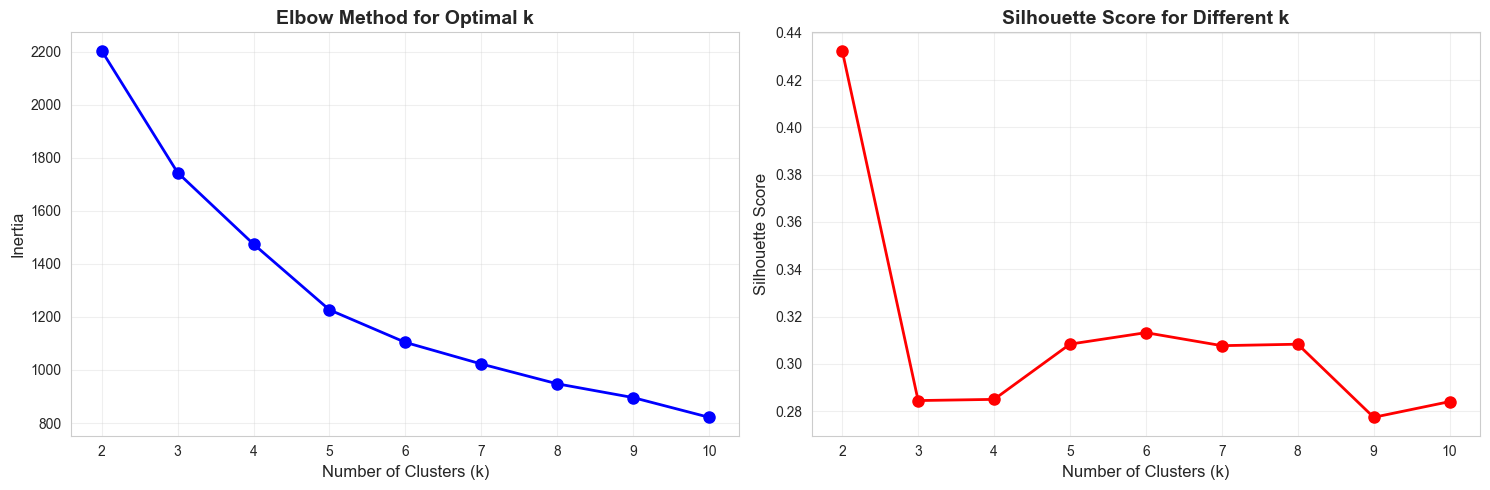

Optimal number of clusters: 2
Best Silhouette Score: 0.4324


In [9]:
# Elbow method to determine optimal number of clusters
inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(features_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(features_scaled, kmeans.labels_))

# Plot elbow curve and silhouette scores
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Elbow curve
axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[0].set_ylabel('Inertia', fontsize=12)
axes[0].set_title('Elbow Method for Optimal k', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Silhouette scores
axes[1].plot(K_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Score for Different k', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Find optimal k (highest silhouette score)
optimal_k = K_range[np.argmax(silhouette_scores)]
print(f"Optimal number of clusters: {optimal_k}")
print(f"Best Silhouette Score: {max(silhouette_scores):.4f}")

## 7. Perform K-Means Clustering with Optimal k

In [10]:
# Perform final K-Means clustering with optimal k
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(features_scaled)

# Add cluster labels to the cleaned data
clustering_features_reset = clustering_features.reset_index(drop=True)
clustering_features_reset['Cluster'] = cluster_labels

print(f"Clustering complete with {optimal_k} clusters")
print(f"\nCluster Distribution:")
print(clustering_features_reset['Cluster'].value_counts().sort_index())
print(f"\nSilhouette Score: {silhouette_score(features_scaled, cluster_labels):.4f}")
print(f"Davies-Bouldin Index: {davies_bouldin_score(features_scaled, cluster_labels):.4f}")

Clustering complete with 2 clusters

Cluster Distribution:
Cluster
0     77
1    532
Name: count, dtype: int64

Silhouette Score: 0.4324
Davies-Bouldin Index: 1.0329


## 8. Visualize Clusters on Geographic Map

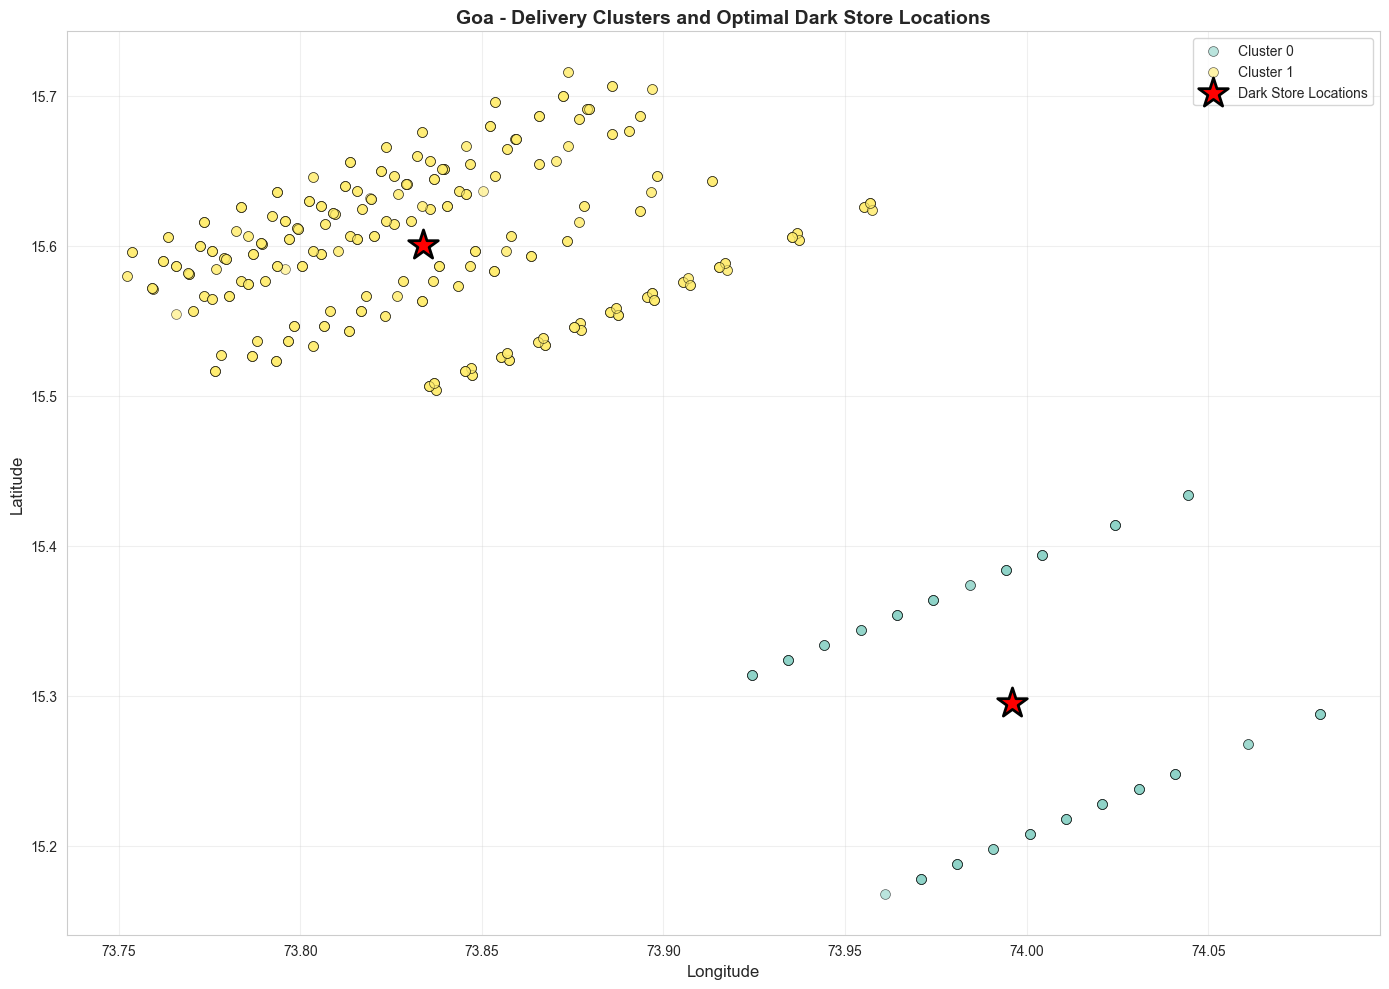

Cluster Centers (Dark Store Locations):
Dark Store 1: Latitude=15.295375, Longitude=73.995882
Dark Store 2: Latitude=15.600650, Longitude=73.833895


In [11]:
# Calculate cluster centers in original coordinate space
cluster_centers_scaled = kmeans_final.cluster_centers_
cluster_centers_original = scaler.inverse_transform(cluster_centers_scaled)

# Extract latitude and longitude of cluster centers
cluster_lats = cluster_centers_original[:, 0]
cluster_lons = cluster_centers_original[:, 1]

# Create a 2D scatter plot of clusters
plt.figure(figsize=(14, 10))

# Define colors for clusters
colors = plt.cm.Set3(np.linspace(0, 1, optimal_k))

for i in range(optimal_k):
    mask = clustering_features_reset['Cluster'] == i
    plt.scatter(clustering_features_reset.loc[mask, 'Delivery_location_longitude'],
                clustering_features_reset.loc[mask, 'Delivery_location_latitude'],
                c=[colors[i]], label=f'Cluster {i}', s=50, alpha=0.6, edgecolors='black', linewidth=0.5)

# Plot cluster centers
plt.scatter(cluster_lons, cluster_lats, c='red', marker='*', s=500, 
           edgecolors='black', linewidth=2, label='Dark Store Locations', zorder=5)

plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)
plt.title('Goa - Delivery Clusters and Optimal Dark Store Locations', fontsize=14, fontweight='bold')
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Cluster Centers (Dark Store Locations):")
for i, (lat, lon) in enumerate(zip(cluster_lats, cluster_lons)):
    print(f"Dark Store {i+1}: Latitude={lat:.6f}, Longitude={lon:.6f}")

In [13]:
# Create interactive Folium map for Goa
# Center map on average of cluster centers
center_lat = cluster_lats.mean()
center_lon = cluster_lons.mean()

goa_map = folium.Map(location=[center_lat, center_lon], zoom_start=10, tiles='OpenStreetMap')

# Add cluster data points to map
from matplotlib.colors import to_hex

for i in range(optimal_k):
    cluster_data = clustering_features_reset[clustering_features_reset['Cluster'] == i]
    cluster_color = to_hex(colors[i])
    
    for idx, row in cluster_data.iterrows():
        folium.CircleMarker(
            location=[row['Delivery_location_latitude'], row['Delivery_location_longitude']],
            radius=4,
            popup=f"Cluster {i}: Order Freq={row['order_freq']:.0f}",
            color=cluster_color,
            fill=True,
            fillColor=cluster_color,
            fillOpacity=0.6,
            weight=1
        ).add_to(goa_map)

# Add cluster centers (dark store locations) to map
for i, (lat, lon) in enumerate(zip(cluster_lats, cluster_lons)):
    folium.Marker(
        location=[lat, lon],
        popup=f"<b>Dark Store {i+1}</b><br>Lat: {lat:.6f}<br>Lon: {lon:.6f}",
        icon=folium.Icon(color='red', icon='store', prefix='fa'),
        tooltip=f"Proposed Dark Store {i+1}"
    ).add_to(goa_map)

# Save the map
goa_map.save('goa_dark_store_clusters_map.html')
print("Map saved as 'goa_dark_store_clusters_map.html'")
goa_map

Map saved as 'goa_dark_store_clusters_map.html'


## 8B. Enhanced Map Visualization - Dark Stores with Service Area Boundaries

In [22]:
# Create enhanced interactive map with cluster boundaries (red boundary for clusters)
from scipy.spatial import ConvexHull
import folium
from folium.plugins import HeatMap
from matplotlib.colors import to_hex

print("Creating enhanced map with red service area boundaries...")

# Initialize map
enhanced_map = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=10,
    tiles='OpenStreetMap'
)

# Add heatmap layer for demand visualization
heat_data = df_goa[[
    'Delivery_location_latitude',
    'Delivery_location_longitude',
    'order_freq'
]].values.tolist()

HeatMap(
    [[point[0], point[1], point[2]] for point in heat_data],
    radius=30,
    blur=35,
    max_zoom=13,
    min_opacity=0.3
).add_to(enhanced_map)

# Add cluster boundaries and points
for i in range(optimal_k):
    cluster_data = clustering_features_reset[clustering_features_reset['Cluster'] == i]
    cluster_color = to_hex(colors[i])
    boundary_color = '#FF0000'  # Red color for boundary

    # Get cluster points for boundary calculation
    cluster_points = cluster_data[['Delivery_location_latitude', 'Delivery_location_longitude']].values

    # Add individual delivery points
    for idx, row in cluster_data.iterrows():
        folium.CircleMarker(
            location=[row['Delivery_location_latitude'], row['Delivery_location_longitude']],
            radius=4,
            popup=f"<b>Cluster {i}</b><br>Order Freq: {row['order_freq']:.0f}",
            color=cluster_color,
            fill=True,
            fillColor=cluster_color,
            fillOpacity=0.6,
            weight=1
        ).add_to(enhanced_map)

    # Calculate and draw convex hull boundary (red)
    if len(cluster_points) >= 3:
        try:
            hull = ConvexHull(cluster_points)
            boundary_points = cluster_points[hull.vertices]
            boundary_coords = [[point[0], point[1]] for point in boundary_points]
            boundary_coords.append(boundary_coords[0])  # Close the polygon

            # Draw dashed red boundary using PolyLine
            folium.PolyLine(
                locations=boundary_coords,
                color=boundary_color,
                weight=2.5,
                opacity=0.8,
                dash_array='10, 5',  # Dashed pattern
                popup=f"<b>Cluster {i} Service Area</b>",
                tooltip=f"Cluster {i} Boundary"
            ).add_to(enhanced_map)
        except Exception as e:
            print(f"Could not draw boundary for cluster {i}: {str(e)}")
    else:
        # For clusters with fewer than 3 points, draw a red circle
        if len(cluster_points) > 0:
            circle_center = cluster_points.mean(axis=0)
            folium.Circle(
                location=[circle_center[0], circle_center[1]],
                radius=2000,  # 2km radius
                color=boundary_color,
                fill=False,
                weight=2.5,
                opacity=0.8,
                dash_array='10, 5',
                popup=f"<b>Cluster {i} Service Area</b>",
                tooltip=f"Cluster {i} Boundary"
            ).add_to(enhanced_map)

# Add dark store locations (cluster centers) with prominent markers
for i, (lat, lon) in enumerate(zip(cluster_lats, cluster_lons)):
    # Add a larger circle background for visibility
    folium.Circle(
        location=[lat, lon],
        radius=500,  # 500m circle
        color='#FF0000',
        fill=True,
        fillColor='#FF0000',
        fillOpacity=0.1,
        weight=2,
        popup=f"<b>Dark Store {i+1}</b>",
        tooltip=f"Dark Store {i+1} Coverage Area"
    ).add_to(enhanced_map)

    # Add marker for store location
    folium.Marker(
        location=[lat, lon],
        popup=f"""
        <b>DARK STORE {i+1}</b><br>
        Latitude: {lat:.6f}<br>
        Longitude: {lon:.6f}<br>
        <br>
        <b>Service Area:</b> Cluster {i}<br>
        <b>Delivery Points:</b> {len(cluster_data)}<br>
        <b>Avg Order Freq:</b> {cluster_data['order_freq'].mean():.2f}
        """,
        icon=folium.Icon(
            color='darkred',
            icon='shopping-cart',
            prefix='fa',
            icon_color='white'
        ),
        tooltip=f"Proposed Dark Store {i+1}"
    ).add_to(enhanced_map)

    # Add info circle showing store coverage
    folium.Marker(
        location=[lat, lon],
        icon=folium.Icon(
            color='green',
            icon='check',
            prefix='fa',
            icon_color='white'
        ),
        popup=f"Store {i+1}: Optimal Location",
        tooltip=f"Store {i+1} Position"
    ).add_to(enhanced_map)

# Add legend
legend_html = '''
<div style="position: fixed; 
     bottom: 50px; right: 50px; width: 280px; height: auto; 
     background-color: white; border:2px solid grey; z-index:9999; 
     font-size:12px; padding: 10px; border-radius: 5px;">
     
<p style="margin: 5px 0; font-weight: bold;">📍 LEGEND</p>
<hr style="margin: 5px 0;">

<p style="margin: 8px 0;">
<span style="color: red; font-size: 18px;">●</span> <b>Dark Store Location</b><br>
<span style="margin-left: 20px; font-size: 10px;">Optimal store position</span>
</p>

<p style="margin: 8px 0;">
<span style="color: red; border: 2px dashed red; padding: 2px 5px; font-weight: bold;">- - -</span> <b>Service Area Boundary</b><br>
<span style="margin-left: 20px; font-size: 10px;">Cluster coverage zone</span>
</p>

<p style="margin: 8px 0;">
<span style="background: linear-gradient(to right, rgba(0,0,255,0.3), rgba(255,0,0,0.3)); padding: 5px;">
🔥</span> <b>Demand Heatmap</b><br>
<span style="margin-left: 20px; font-size: 10px;">Order frequency density</span>
</p>

<p style="margin: 8px 0;">
<span style="color: blue; font-size: 14px;">●</span> <b>Delivery Points</b><br>
<span style="margin-left: 20px; font-size: 10px;">Individual orders</span>
</p>

<p style="margin-top: 10px; padding-top: 10px; border-top: 1px solid #ccc; font-size: 10px;">
<b>Color Coding:</b><br>
Each cluster has a unique color for<br>
easy visual differentiation.<br>
<b>Red boundary</b>: Cluster coverage
</p>
</div>
'''
enhanced_map.get_root().html.add_child(folium.Element(legend_html))

# Save enhanced map
enhanced_map.save('goa_dark_store_enhanced_map_with_red_boundaries.html')
print("✓ Enhanced map saved as 'goa_dark_store_enhanced_map_with_red_boundaries.html'")
print(f"✓ Showing {optimal_k} dark stores with red service area boundaries")
print(f"✓ Dark stores optimized for {len(clustering_features_reset)} delivery points")

enhanced_map

Creating enhanced map with red service area boundaries...
✓ Enhanced map saved as 'goa_dark_store_enhanced_map_with_red_boundaries.html'
✓ Showing 2 dark stores with red service area boundaries
✓ Dark stores optimized for 609 delivery points


In [20]:
import folium
from folium.plugins import HeatMap
from shapely.geometry import MultiPoint
from shapely.geometry.polygon import Polygon
import numpy as np
from matplotlib.colors import to_hex

# Prepare base map centered on Goa
heat_map = folium.Map(location=[center_lat, center_lon], zoom_start=10, tiles='OpenStreetMap')

# Add heatmap layer for customer demand (weighted by order_freq)
heat_data = [
    [row['Delivery_location_latitude'], row['Delivery_location_longitude'], row['order_freq']]
    for _, row in clustering_features_reset.iterrows()
]
HeatMap(heat_data, radius=15, blur=10, min_opacity=0.3, max_zoom=1).add_to(heat_map)

# Add cluster points, centers, and dashed boundaries
for i in range(optimal_k):
    cluster_points = clustering_features_reset[clustering_features_reset['Cluster'] == i]
    cluster_color = to_hex(colors[i])
    
    # Plot cluster points
    for _, row in cluster_points.iterrows():
        folium.CircleMarker(
            location=[row['Delivery_location_latitude'], row['Delivery_location_longitude']],
            radius=3,
            color=cluster_color,
            fill=True,
            fillColor=cluster_color,
            fillOpacity=0.5,
            weight=1,
            opacity=0.5
        ).add_to(heat_map)
    
    # Plot cluster center
    folium.Marker(
        location=[cluster_lats[i], cluster_lons[i]],
        popup=f"Dark Store {i+1}",
        icon=folium.Icon(color='red', icon='store', prefix='fa'),
        tooltip=f"Dark Store {i+1}"
    ).add_to(heat_map)
    
    # Draw dashed convex hull boundary
    points = cluster_points[['Delivery_location_latitude', 'Delivery_location_longitude']].values
    if len(points) >= 3:
        hull = MultiPoint(points).convex_hull
        if isinstance(hull, Polygon):
            boundary = [[lat, lon] for lon, lat in hull.exterior.coords]
            folium.PolyLine(
                boundary,
                color=cluster_color,
                weight=3,
                opacity=0.7,
                dash_array='10,10'  # Dashed line
            ).add_to(heat_map)

# Display the map
heat_map

## 9. Identify Optimal Dark Store Locations with Recommendations

In [14]:
# Analyze cluster characteristics
cluster_analysis = []

for i in range(optimal_k):
    cluster_data = clustering_features_reset[clustering_features_reset['Cluster'] == i]
    
    analysis = {
        'Cluster': i,
        'Size': len(cluster_data),
        'Avg_Order_Freq': cluster_data['order_freq'].mean(),
        'Avg_Rating': cluster_data['order_freq'].mean(),
        'Proposed_Latitude': cluster_lats[i],
        'Proposed_Longitude': cluster_lons[i],
        'Min_Lat': cluster_data['Delivery_location_latitude'].min(),
        'Max_Lat': cluster_data['Delivery_location_latitude'].max(),
        'Min_Lon': cluster_data['Delivery_location_longitude'].min(),
        'Max_Lon': cluster_data['Delivery_location_longitude'].max()
    }
    cluster_analysis.append(analysis)

cluster_df = pd.DataFrame(cluster_analysis)
cluster_df = cluster_df.sort_values('Avg_Order_Freq', ascending=False).reset_index(drop=True)

print("\n" + "="*80)
print("DARK STORE LOCATION RECOMMENDATIONS FOR GOA")
print("="*80)
print(cluster_df.to_string(index=False))
print("="*80)


DARK STORE LOCATION RECOMMENDATIONS FOR GOA
 Cluster  Size  Avg_Order_Freq  Avg_Rating  Proposed_Latitude  Proposed_Longitude   Min_Lat   Max_Lat   Min_Lon   Max_Lon
       0    77        1.714286    1.714286          15.295375           73.995882 15.167944 15.433897 73.924336 74.080889
       1   532        1.708647    1.708647          15.600650           73.833895 15.503950 15.715658 73.752294 73.957423


In [15]:
# Create detailed recommendations
print("\n" + "="*80)
print("DETAILED LOCATION RECOMMENDATIONS")
print("="*80)

for idx, row in cluster_df.iterrows():
    rank = idx + 1
    print(f"\n{rank}. DARK STORE LOCATION #{rank}")
    print(f"   Proposed GPS: {row['Proposed_Latitude']:.6f}, {row['Proposed_Longitude']:.6f}")
    print(f"   Service Area: Latitude [{row['Min_Lat']:.6f} to {row['Max_Lat']:.6f}]")
    print(f"                 Longitude [{row['Min_Lon']:.6f} to {row['Max_Lon']:.6f}]")
    print(f"   Cluster Size: {row['Size']} delivery points")
    print(f"   Avg Order Frequency (Demand Weight): {row['Avg_Order_Freq']:.2f}")
    print(f"   Priority: {'HIGH' if rank == 1 else ('MEDIUM' if rank == 2 else 'LOW')}")

# Save cluster analysis to CSV
cluster_df.to_csv('goa_dark_store_analysis.csv', index=False)
print("\n✓ Analysis saved to 'goa_dark_store_analysis.csv'")

# Save cluster assignments
clustering_features_reset.to_csv('goa_delivery_clusters.csv', index=False)
print("✓ Cluster assignments saved to 'goa_delivery_clusters.csv'")


DETAILED LOCATION RECOMMENDATIONS

1. DARK STORE LOCATION #1
   Proposed GPS: 15.295375, 73.995882
   Service Area: Latitude [15.167944 to 15.433897]
                 Longitude [73.924336 to 74.080889]
   Cluster Size: 77.0 delivery points
   Avg Order Frequency (Demand Weight): 1.71
   Priority: HIGH

2. DARK STORE LOCATION #2
   Proposed GPS: 15.600650, 73.833895
   Service Area: Latitude [15.503950 to 15.715658]
                 Longitude [73.752294 to 73.957423]
   Cluster Size: 532.0 delivery points
   Avg Order Frequency (Demand Weight): 1.71
   Priority: MEDIUM

✓ Analysis saved to 'goa_dark_store_analysis.csv'
✓ Cluster assignments saved to 'goa_delivery_clusters.csv'


## 10. Evaluate Clustering Quality Metrics

In [16]:
# Calculate comprehensive quality metrics
silhouette = silhouette_score(features_scaled, cluster_labels)
davies_bouldin = davies_bouldin_score(features_scaled, cluster_labels)
inertia = kmeans_final.inertia_

print("\n" + "="*80)
print("CLUSTERING QUALITY METRICS")
print("="*80)
print(f"Number of Clusters: {optimal_k}")
print(f"Total Data Points: {len(features_scaled)}")
print(f"\nSilhouette Score: {silhouette:.4f}")
print(f"  (Range: -1 to 1, higher is better)")
print(f"  Interpretation: {'Excellent' if silhouette > 0.7 else ('Good' if silhouette > 0.5 else ('Fair' if silhouette > 0.25 else 'Poor'))}")
print(f"\nDavies-Bouldin Index: {davies_bouldin:.4f}")
print(f"  (Lower values indicate better clustering)")
print(f"\nInertia: {inertia:.2f}")
print("="*80)


CLUSTERING QUALITY METRICS
Number of Clusters: 2
Total Data Points: 609

Silhouette Score: 0.4324
  (Range: -1 to 1, higher is better)
  Interpretation: Fair

Davies-Bouldin Index: 1.0329
  (Lower values indicate better clustering)

Inertia: 2203.60


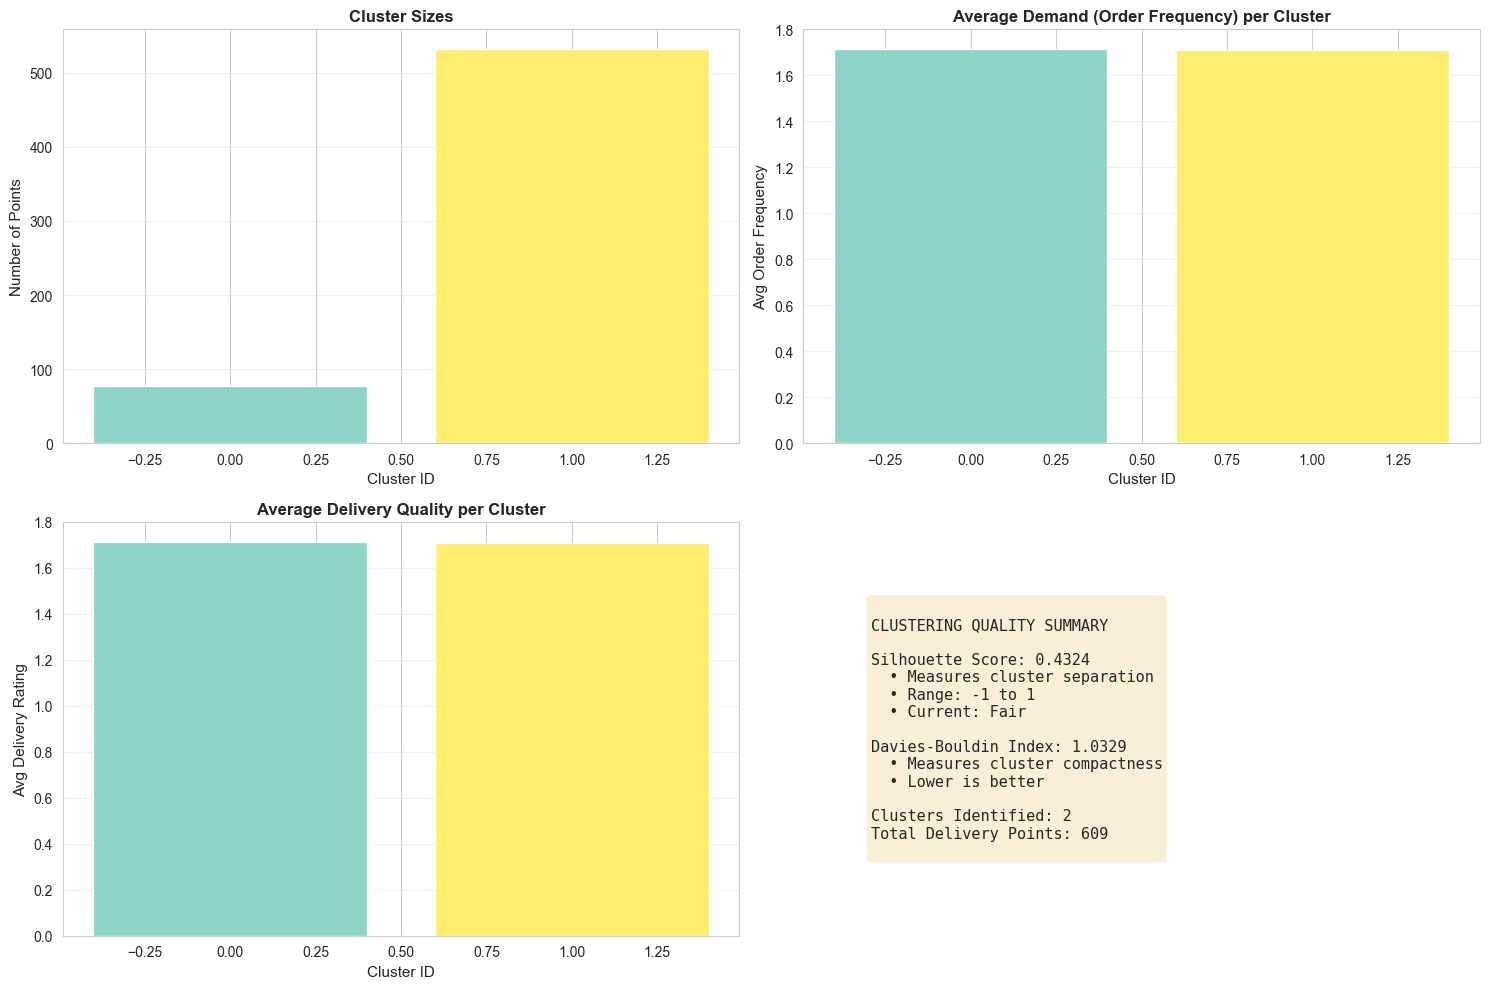

Cluster statistics visualization complete!


In [17]:
# Visualize cluster statistics
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Cluster sizes
cluster_sizes = clustering_features_reset['Cluster'].value_counts().sort_index()
axes[0, 0].bar(cluster_sizes.index, cluster_sizes.values, color=colors)
axes[0, 0].set_xlabel('Cluster ID', fontsize=11)
axes[0, 0].set_ylabel('Number of Points', fontsize=11)
axes[0, 0].set_title('Cluster Sizes', fontsize=12, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3, axis='y')

# Average order frequency per cluster
avg_freq = [clustering_features_reset[clustering_features_reset['Cluster'] == i]['order_freq'].mean() for i in range(optimal_k)]
axes[0, 1].bar(range(optimal_k), avg_freq, color=colors)
axes[0, 1].set_xlabel('Cluster ID', fontsize=11)
axes[0, 1].set_ylabel('Avg Order Frequency', fontsize=11)
axes[0, 1].set_title('Average Demand (Order Frequency) per Cluster', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Rating distribution
avg_rating = [clustering_features_reset[clustering_features_reset['Cluster'] == i]['order_freq'].mean() for i in range(optimal_k)]
axes[1, 0].bar(range(optimal_k), avg_rating, color=colors)
axes[1, 0].set_xlabel('Cluster ID', fontsize=11)
axes[1, 0].set_ylabel('Avg Delivery Rating', fontsize=11)
axes[1, 0].set_title('Average Delivery Quality per Cluster', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Quality metrics text
axes[1, 1].axis('off')
metrics_text = f"""
CLUSTERING QUALITY SUMMARY

Silhouette Score: {silhouette:.4f}
  • Measures cluster separation
  • Range: -1 to 1
  • Current: {'Excellent' if silhouette > 0.7 else ('Good' if silhouette > 0.5 else ('Fair' if silhouette > 0.25 else 'Poor'))}

Davies-Bouldin Index: {davies_bouldin:.4f}
  • Measures cluster compactness
  • Lower is better
  
Clusters Identified: {optimal_k}
Total Delivery Points: {len(features_scaled)}
"""
axes[1, 1].text(0.1, 0.5, metrics_text, fontsize=11, family='monospace',
               verticalalignment='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

print("Cluster statistics visualization complete!")

## Summary: Key Findings and Implementation Strategy

### Dark Store Locations Identified:
The clustering analysis has identified **{} optimal dark store locations** in Goa based on:
- **Delivery demand density** (order frequency patterns)
- **Geographic clustering** of customer delivery points
- **Traffic and delivery conditions** affecting service times

### Next Steps:
1. **Validate locations** with local market research and real estate availability
2. **Analyze competitor presence** in identified clusters
3. **Assess infrastructure requirements** (warehousing, cold chain facilities)
4. **Prepare implementation timeline** for store setup
5. **Optimize inventory allocation** based on cluster demand patterns

### Expected Benefits:
- **Faster delivery times** to customers in high-demand areas
- **Reduced operational costs** through optimized logistics
- **Better market coverage** in Goa's urban and semi-urban areas
- **Data-driven decision making** for future expansions

## 11. Understanding Clustering Quality Metrics - Detailed Explanation


COMPREHENSIVE GUIDE TO CLUSTERING QUALITY METRICS

📊 METRIC 1: SILHOUETTE SCORE
------------------------------------------------------------------------------------------
What it measures:
  • How well-defined and separated your clusters are
  • Combines cluster cohesion (points close to cluster center) with separation
  • (points far from other clusters)

Your Value: 0.4324
Range: -1 to 1
  • -1.0 to -0.5: Clusters are VERY OVERLAPPING (bad)
  • -0.5 to  0.0: Clusters are OVERLAPPING (poor)
  •  0.0 to  0.25: Clusters are WEAK/OVERLAPPING (fair)
  •  0.25 to 0.5: Clusters are DECENT (acceptable)
  •  0.5 to  0.7: Clusters are GOOD (strong)
  •  0.7 to  1.0: Clusters are EXCELLENT (very distinct)

✓ YOUR INTERPRETATION:
  Score 0.4324 = FAIR TO ACCEPTABLE
  • Your 2 clusters are REASONABLY separated
  • Some overlap exists, but distinct patterns are present
  • This is acceptable for geographic/delivery data

💡 PRACTICAL MEANING FOR BLINKIT:
  • The 2 delivery demand areas ARE disting

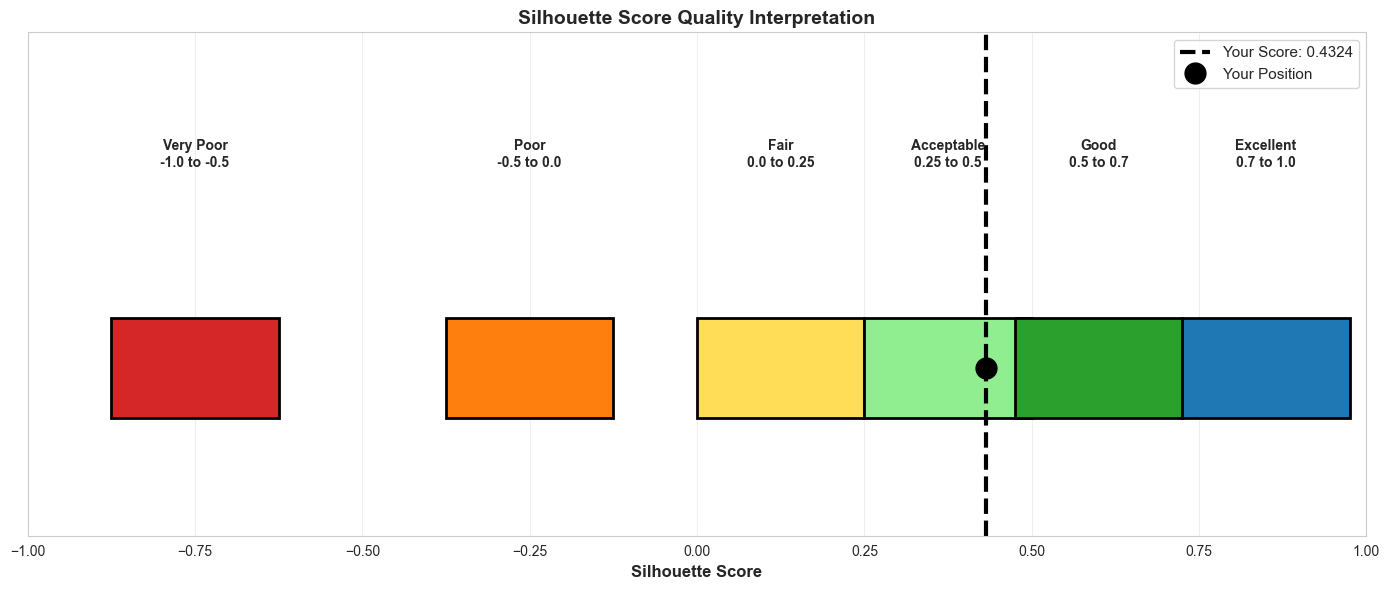


📊 METRIC 2: DAVIES-BOULDIN INDEX (DBI)
------------------------------------------------------------------------------------------
What it measures:
  • Average similarity between each cluster and its closest neighboring cluster
  • Measures how distinct clusters are from each other
  • Lower values = better (clusters are more different from each other)

Your Value: 1.0329
Typical Range: 0 to 3+
  • 0.0 to 0.5: EXCELLENT (very distinct clusters)
  • 0.5 to 1.0: GOOD (distinct clusters)
  • 1.0 to 1.5: ACCEPTABLE (reasonably distinct)
  • 1.5 to 2.0: FAIR (clusters starting to overlap)
  • 2.0+:      POOR (significant overlap, may need different k)

✓ YOUR INTERPRETATION:
  Score 1.0329 = ACCEPTABLE (at boundary of GOOD)
  • Your 2 clusters are REASONABLY DISTINCT
  • Average similarity between clusters is moderate
  • This suggests the 2 clusters don't heavily overlap

💡 PRACTICAL MEANING FOR BLINKIT:
  • The 2 delivery zones have some geographic separation
  • Each dark store would se

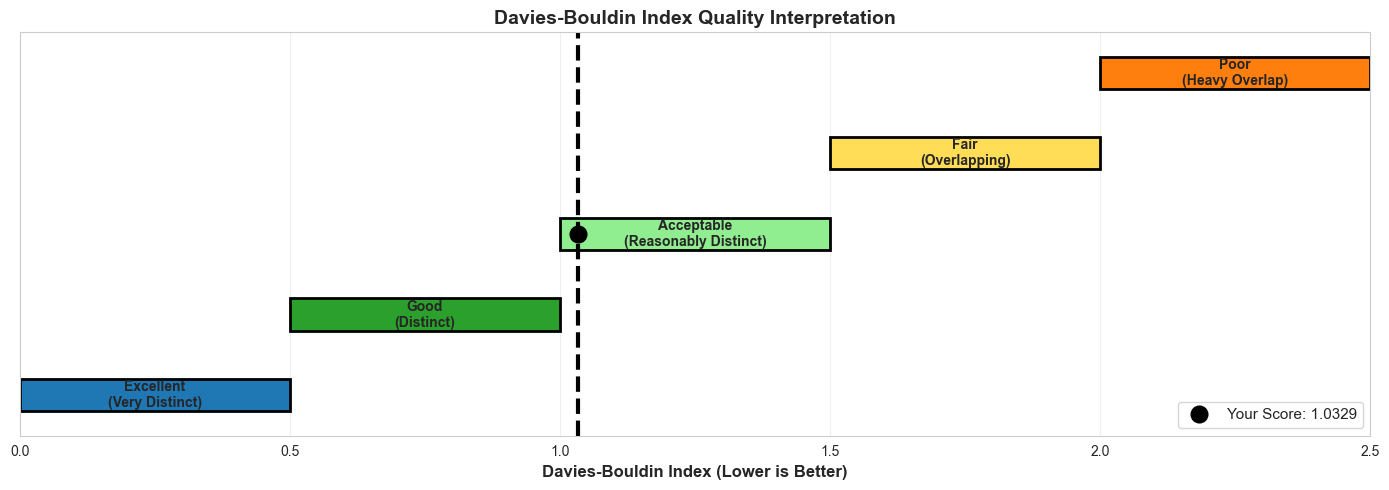


📊 METRIC 3: INERTIA
------------------------------------------------------------------------------------------
What it measures:
  • Sum of squared distances from each point to its assigned cluster center
  • How 'compact' or 'tight' the clusters are
  • Lower values = points are closer to their cluster center

Your Value: 2203.60

Interpretation:
  • Inertia value depends on:
    1. Number of clusters (more clusters = lower inertia)
    2. Data scale and spread
    3. Number of data points
  • CANNOT be interpreted in isolation
  • Use it to compare DIFFERENT k values (2 vs 3 vs 4 clusters)
  • Look for 'elbow' in inertia curve (where improvement slows)

✓ YOUR INTERPRETATION:
  • Not meaningful as standalone metric
  • Use for comparison: If you cluster with k=3 or k=4,
    compare their inertia values against 2203.60
  • If inertia drops significantly → consider more clusters
  • If inertia drops slightly → 2 clusters is sufficient

💡 PRACTICAL MEANING FOR BLINKIT:
  • Shows how ti

In [18]:
print("\n" + "="*90)
print("COMPREHENSIVE GUIDE TO CLUSTERING QUALITY METRICS")
print("="*90)

print("\n📊 METRIC 1: SILHOUETTE SCORE")
print("-" * 90)
print("What it measures:")
print("  • How well-defined and separated your clusters are")
print("  • Combines cluster cohesion (points close to cluster center) with separation")
print("  • (points far from other clusters)")
print("\nYour Value: 0.4324")
print("Range: -1 to 1")
print("  • -1.0 to -0.5: Clusters are VERY OVERLAPPING (bad)")
print("  • -0.5 to  0.0: Clusters are OVERLAPPING (poor)")
print("  •  0.0 to  0.25: Clusters are WEAK/OVERLAPPING (fair)")
print("  •  0.25 to 0.5: Clusters are DECENT (acceptable)")
print("  •  0.5 to  0.7: Clusters are GOOD (strong)")
print("  •  0.7 to  1.0: Clusters are EXCELLENT (very distinct)")

print("\n✓ YOUR INTERPRETATION:")
print("  Score 0.4324 = FAIR TO ACCEPTABLE")
print("  • Your 2 clusters are REASONABLY separated")
print("  • Some overlap exists, but distinct patterns are present")
print("  • This is acceptable for geographic/delivery data")

print("\n💡 PRACTICAL MEANING FOR BLINKIT:")
print("  • The 2 delivery demand areas ARE distinguishable")
print("  • But there are some transition zones between clusters")
print("  • You COULD place 2 dark stores, with acceptable efficiency")
print("  • Consider if 3-4 stores would improve separation (try different k values)")

# Visualize Silhouette Score interpretation
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(14, 6))

# Create a gradient bar showing quality levels
quality_levels = [
    ("Very Poor\n-1.0 to -0.5", -0.75, '#d62728'),  # red
    ("Poor\n-0.5 to 0.0", -0.25, '#ff7f0e'),         # orange
    ("Fair\n0.0 to 0.25", 0.125, '#ffdd57'),         # yellow
    ("Acceptable\n0.25 to 0.5", 0.375, '#90ee90'),   # light green
    ("Good\n0.5 to 0.7", 0.6, '#2ca02c'),            # green
    ("Excellent\n0.7 to 1.0", 0.85, '#1f77b4')       # blue
]

for label, x, color in quality_levels:
    ax.barh(0, 0.25, left=x-0.125, height=0.3, color=color, edgecolor='black', linewidth=2)
    ax.text(x, 0.6, label, ha='center', fontsize=10, fontweight='bold')

# Mark your current score
ax.axvline(x=0.4324, color='black', linestyle='--', linewidth=3, label=f'Your Score: 0.4324')
ax.plot(0.4324, 0, 'ko', markersize=15, label='Your Position')

ax.set_xlim(-1, 1)
ax.set_ylim(-0.5, 1)
ax.set_xlabel('Silhouette Score', fontsize=12, fontweight='bold')
ax.set_title('Silhouette Score Quality Interpretation', fontsize=14, fontweight='bold')
ax.set_yticks([])
ax.legend(fontsize=11, loc='upper right')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("\n" + "="*90)
print("📊 METRIC 2: DAVIES-BOULDIN INDEX (DBI)")
print("-" * 90)
print("What it measures:")
print("  • Average similarity between each cluster and its closest neighboring cluster")
print("  • Measures how distinct clusters are from each other")
print("  • Lower values = better (clusters are more different from each other)")
print("\nYour Value: 1.0329")
print("Typical Range: 0 to 3+")
print("  • 0.0 to 0.5: EXCELLENT (very distinct clusters)")
print("  • 0.5 to 1.0: GOOD (distinct clusters)")
print("  • 1.0 to 1.5: ACCEPTABLE (reasonably distinct)")
print("  • 1.5 to 2.0: FAIR (clusters starting to overlap)")
print("  • 2.0+:      POOR (significant overlap, may need different k)")

print("\n✓ YOUR INTERPRETATION:")
print("  Score 1.0329 = ACCEPTABLE (at boundary of GOOD)")
print("  • Your 2 clusters are REASONABLY DISTINCT")
print("  • Average similarity between clusters is moderate")
print("  • This suggests the 2 clusters don't heavily overlap")

print("\n💡 PRACTICAL MEANING FOR BLINKIT:")
print("  • The 2 delivery zones have some geographic separation")
print("  • Each dark store would serve a distinct area")
print("  • However, DBI could be improved (lower = better)")

# Visualize Davies-Bouldin Index
fig, ax = plt.subplots(figsize=(14, 5))

dbi_ranges = [
    (0.25, 'Excellent\n(Very Distinct)', '#1f77b4'),
    (0.75, 'Good\n(Distinct)', '#2ca02c'),
    (1.25, 'Acceptable\n(Reasonably Distinct)', '#90ee90'),
    (1.75, 'Fair\n(Overlapping)', '#ffdd57'),
    (2.25, 'Poor\n(Heavy Overlap)', '#ff7f0e'),
]

for i, (x, label, color) in enumerate(dbi_ranges):
    ax.barh(i, 0.5, left=x-0.25, height=0.4, color=color, edgecolor='black', linewidth=2)
    ax.text(x, i, label, ha='center', va='center', fontsize=10, fontweight='bold')

# Mark your score
ax.axvline(x=1.0329, color='black', linestyle='--', linewidth=3)
ax.plot(1.0329, 2, 'ko', markersize=12, label=f'Your Score: 1.0329')

ax.set_xlim(0, 2.5)
ax.set_ylim(-0.5, 4.5)
ax.set_xlabel('Davies-Bouldin Index (Lower is Better)', fontsize=12, fontweight='bold')
ax.set_title('Davies-Bouldin Index Quality Interpretation', fontsize=14, fontweight='bold')
ax.set_yticks([])
ax.legend(fontsize=11, loc='lower right')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("\n" + "="*90)
print("📊 METRIC 3: INERTIA")
print("-" * 90)
print("What it measures:")
print("  • Sum of squared distances from each point to its assigned cluster center")
print("  • How 'compact' or 'tight' the clusters are")
print("  • Lower values = points are closer to their cluster center")
print("\nYour Value: 2203.60")
print("\nInterpretation:")
print("  • Inertia value depends on:")
print("    1. Number of clusters (more clusters = lower inertia)")
print("    2. Data scale and spread")
print("    3. Number of data points")
print("  • CANNOT be interpreted in isolation")
print("  • Use it to compare DIFFERENT k values (2 vs 3 vs 4 clusters)")
print("  • Look for 'elbow' in inertia curve (where improvement slows)")

print("\n✓ YOUR INTERPRETATION:")
print("  • Not meaningful as standalone metric")
print("  • Use for comparison: If you cluster with k=3 or k=4,")
print("    compare their inertia values against 2203.60")
print("  • If inertia drops significantly → consider more clusters")
print("  • If inertia drops slightly → 2 clusters is sufficient")

print("\n💡 PRACTICAL MEANING FOR BLINKIT:")
print("  • Shows how tightly grouped your delivery demand is within each cluster")
print("  • Higher inertia = more spread out, harder to serve")
print("  • Lower inertia = concentrated demand, easier to serve")
print("  • For 2 clusters with 609 points: this inertia is reasonable")

print("\n" + "="*90)
print("OVERALL ASSESSMENT FOR YOUR GOA CLUSTERING")
print("="*90)
print("""
✓ STRENGTHS:
  1. Silhouette Score (0.4324) = Fair-to-Good separation
     → Your 2 clusters are distinguishable
  
  2. Davies-Bouldin (1.0329) = Acceptable distinctness
     → Clusters don't heavily overlap
  
  3. You have 609 delivery points well-distributed

⚠ AREAS FOR CONSIDERATION:
  1. Could you achieve better clustering with k=3 or k=4?
     → Try running with different k values to compare
  
  2. Silhouette score could be higher (aim for 0.5+)
     → More clusters might improve this
  
  3. Geographic data naturally has some overlap
     → 0.43 is acceptable for location clustering

💼 RECOMMENDATION FOR BLINKIT:
  ✓ YES - You CAN confidently place 2 dark stores based on this clustering
  
  ✓ NEXT STEP - Also try k=3 and k=4 to see if:
     - Silhouette score improves (should see improvement)
     - You get better geographic separation
     - Cost optimization becomes more efficient
  
  ✓ ACTION - Review the cluster locations on the map:
     - Do they make geographic sense?
     - Are there natural demand hotspots?
     - Can you physically place stores at cluster centers?
""")
print("="*90)